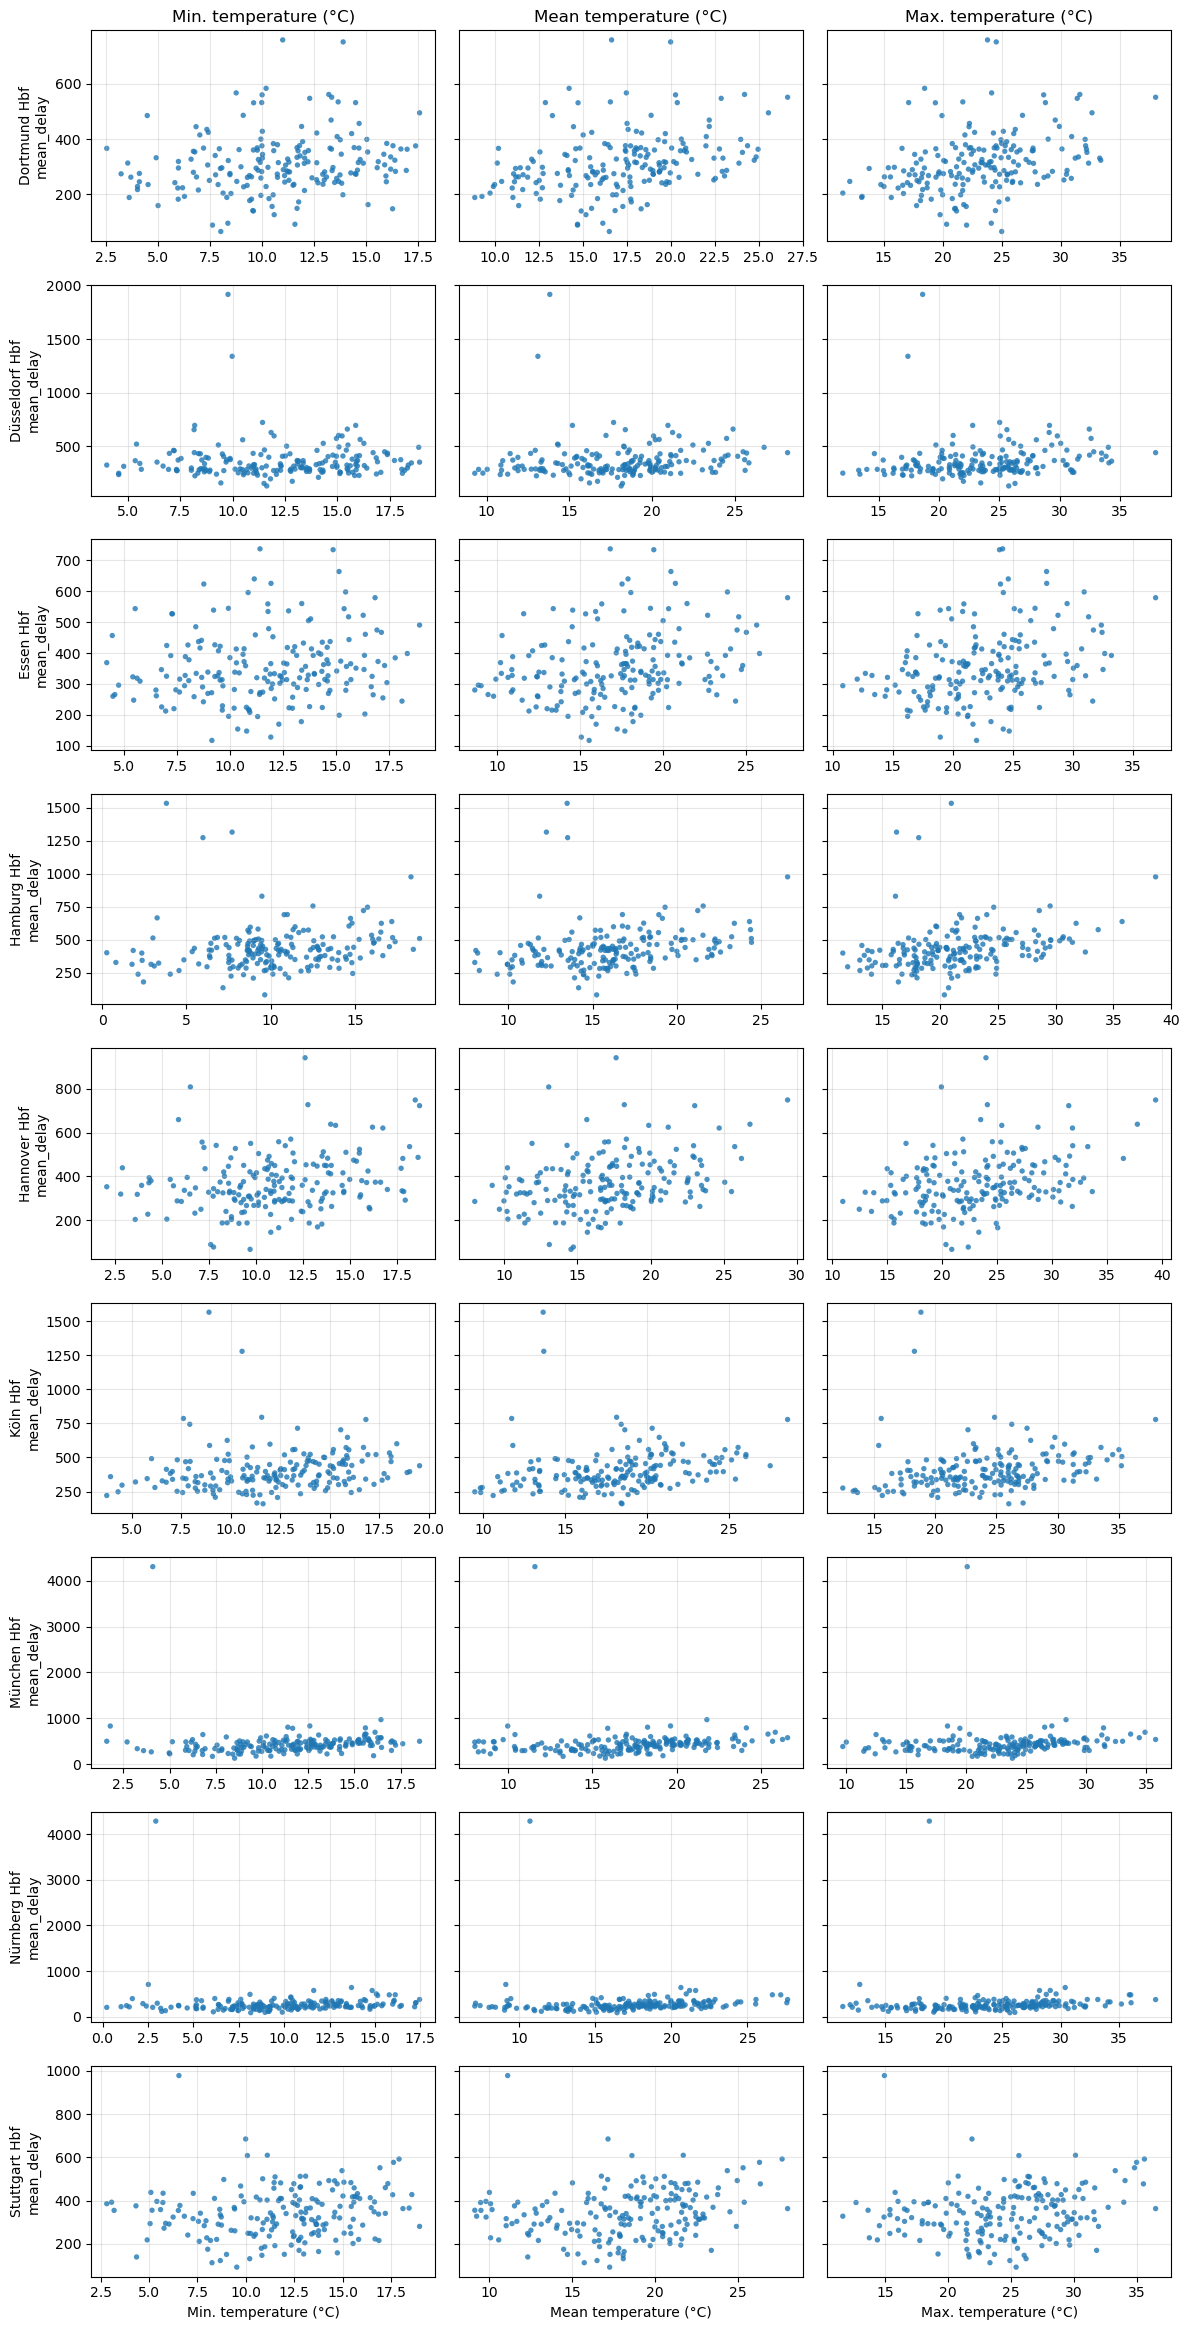

In [3]:
import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "mean_delay"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")
        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()
#print("saved:", out_file)

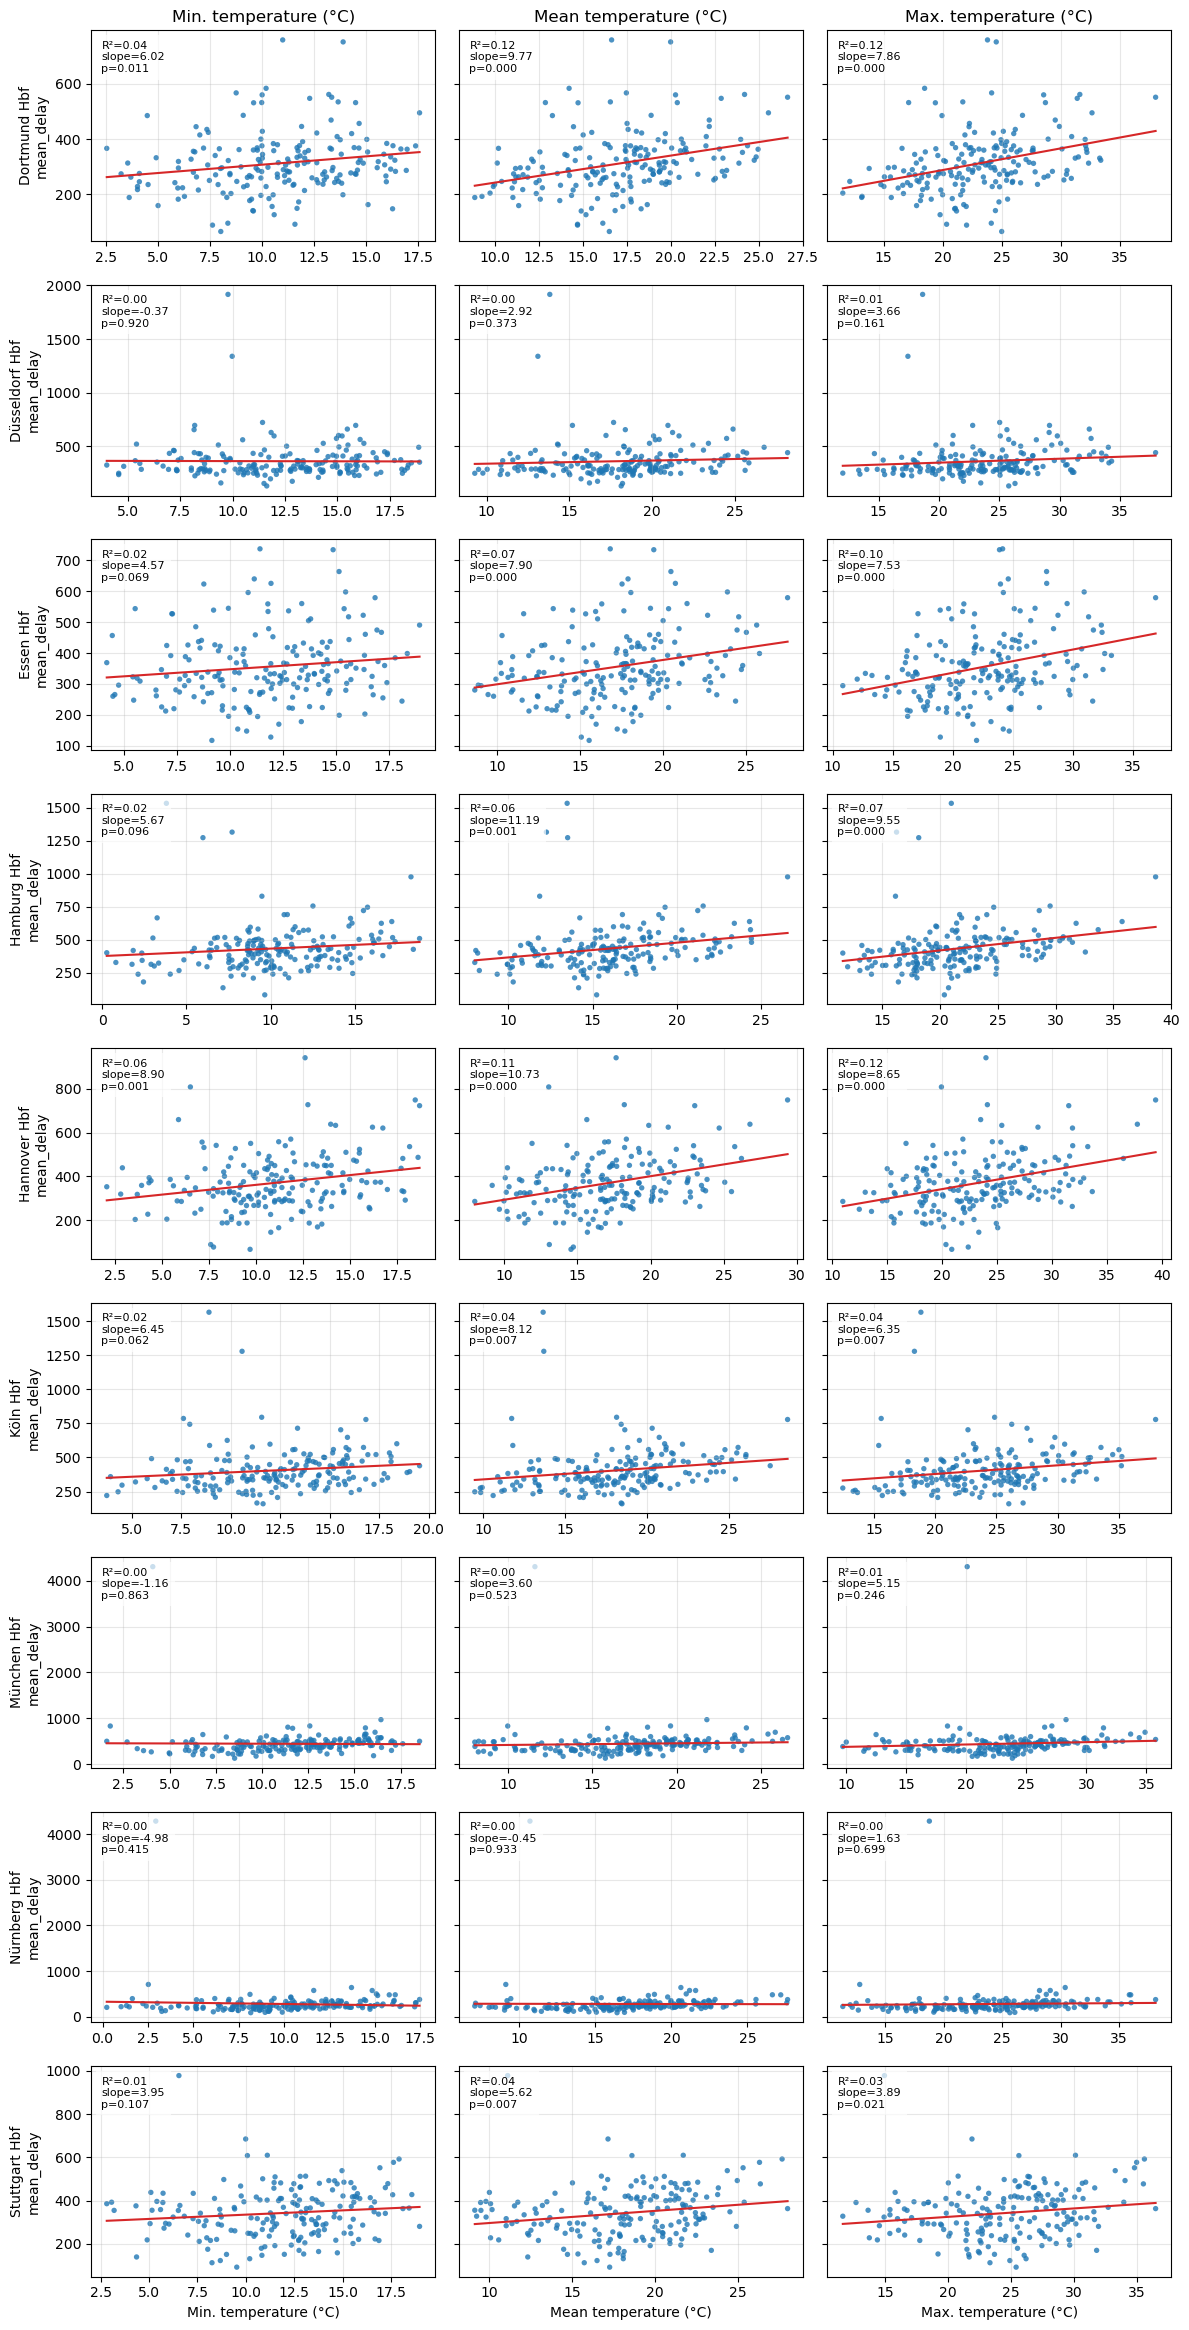

          city variable   n  slope  intercept      r    R2  p_value  stderr_slope
  Dortmund Hbf       tn 185  6.020    246.812  0.187 0.035    0.011         2.332
  Dortmund Hbf       tg 185  9.771    144.500  0.340 0.115    0.000         2.001
  Dortmund Hbf       tx 185  7.858    130.536  0.347 0.121    0.000         1.569
Düsseldorf Hbf       tn 185 -0.374    365.151 -0.007 0.000    0.920         3.703
Düsseldorf Hbf       tg 185  2.916    308.087  0.066 0.004    0.373         3.268
Düsseldorf Hbf       tx 185  3.663    273.646  0.103 0.011    0.161         2.604
     Essen Hbf       tn 185  4.571    301.642  0.134 0.018    0.069         2.498
     Essen Hbf       tg 185  7.903    219.602  0.273 0.074    0.000         2.063
     Essen Hbf       tx 185  7.530    185.373  0.320 0.102    0.000         1.649
   Hamburg Hbf       tn 185  5.668    375.166  0.123 0.015    0.096         3.386
   Hamburg Hbf       tg 185 11.190    253.131  0.238 0.057    0.001         3.372
   Hamburg Hbf  

In [4]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "mean_delay"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

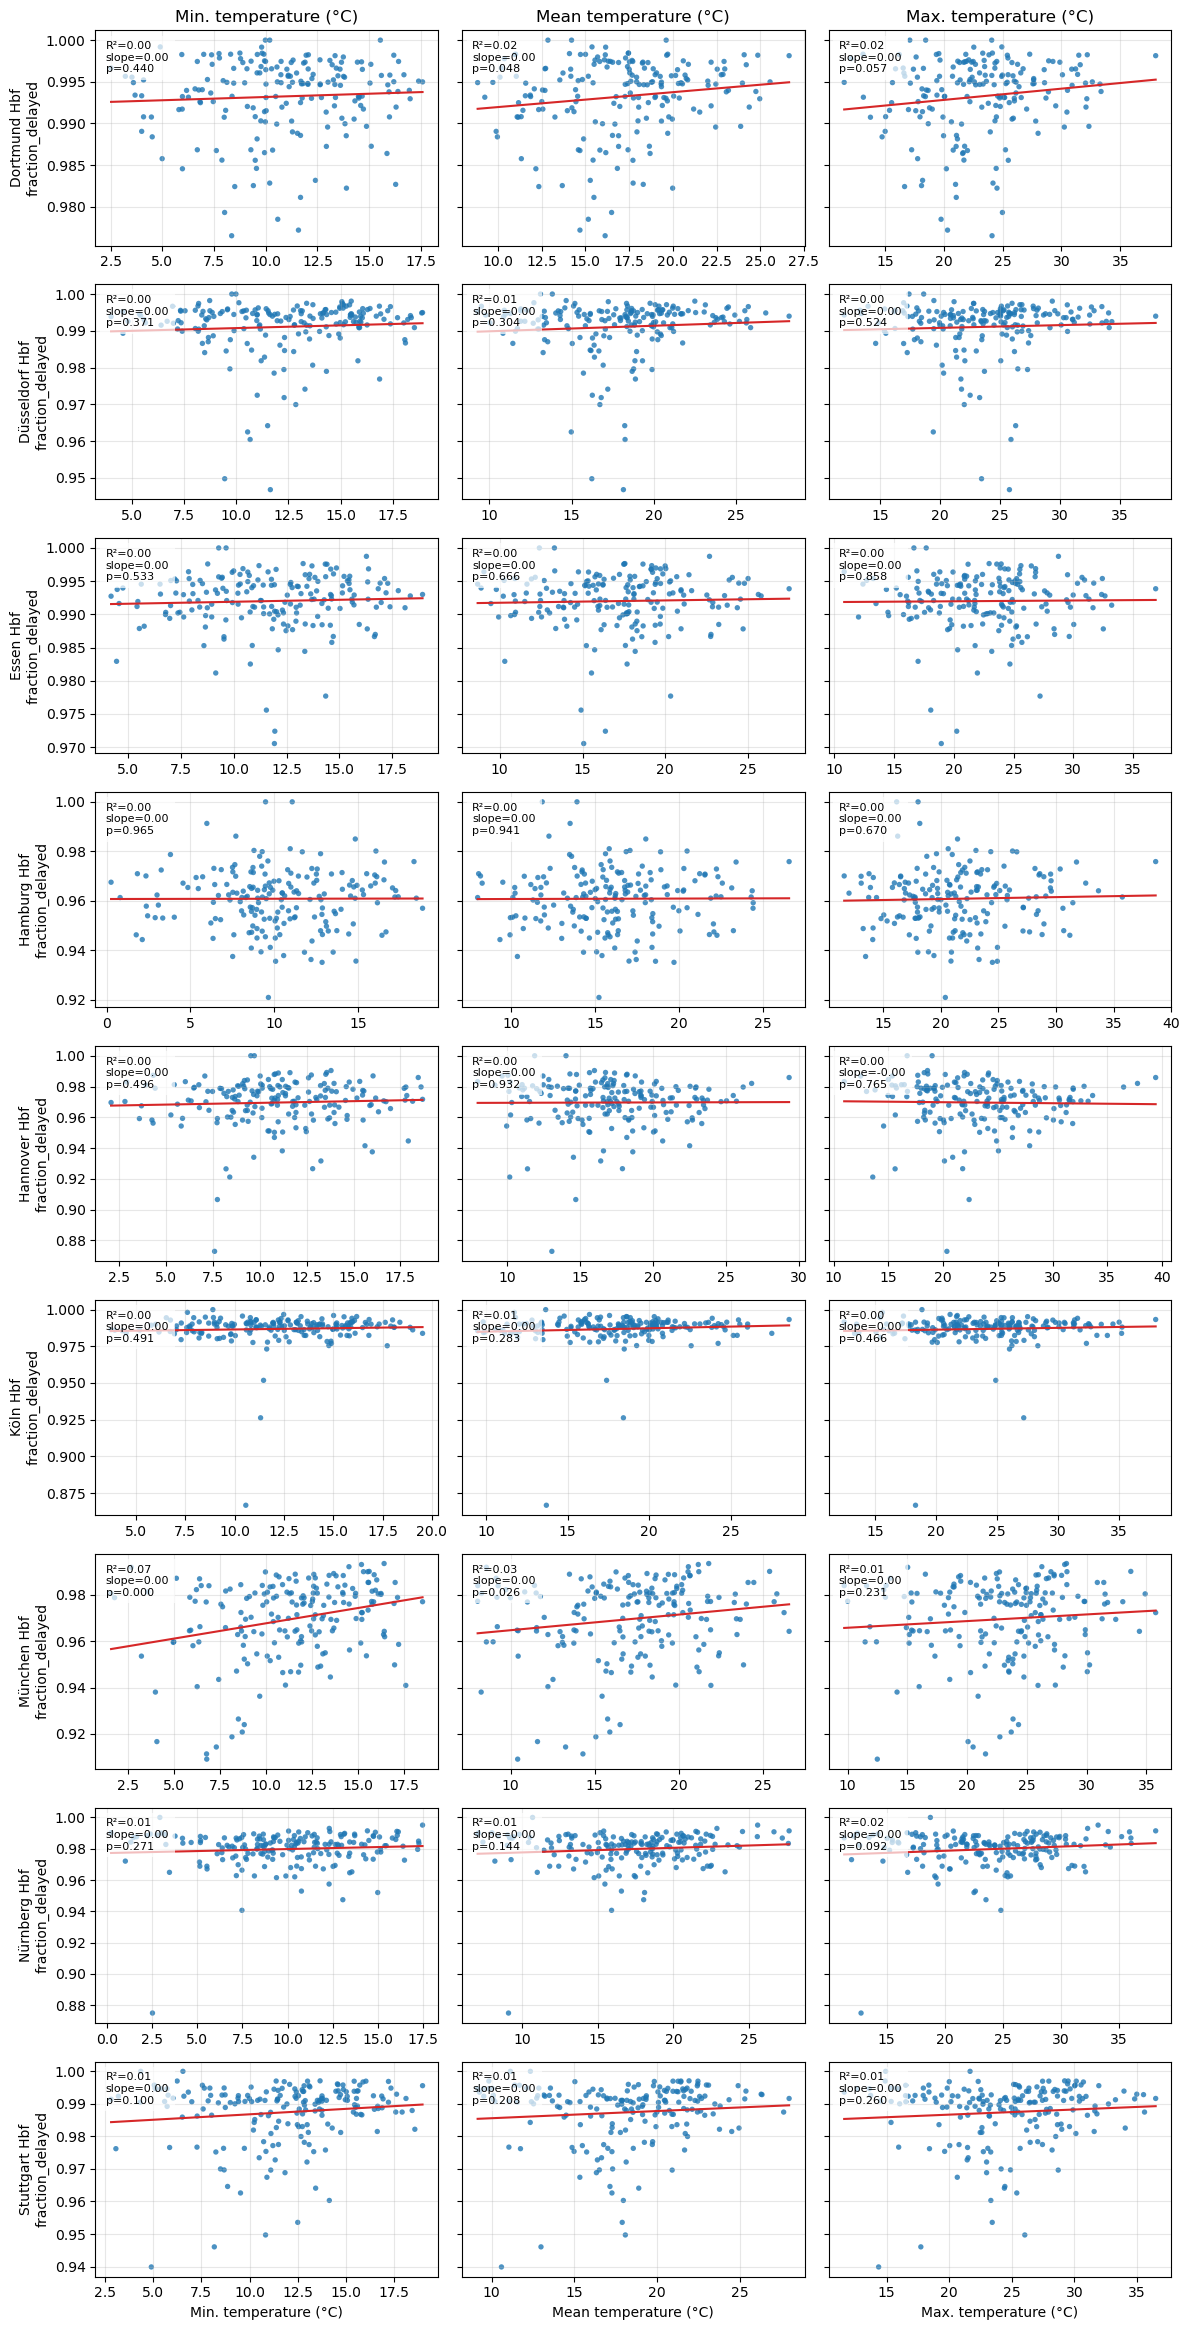

          city variable   n  slope  intercept      r    R2  p_value  stderr_slope
  Dortmund Hbf       tn 185  0.000      0.992  0.057 0.003    0.440           0.0
  Dortmund Hbf       tg 185  0.000      0.990  0.146 0.021    0.048           0.0
  Dortmund Hbf       tx 185  0.000      0.990  0.140 0.020    0.057           0.0
Düsseldorf Hbf       tn 185  0.000      0.989  0.066 0.004    0.371           0.0
Düsseldorf Hbf       tg 185  0.000      0.988  0.076 0.006    0.304           0.0
Düsseldorf Hbf       tx 185  0.000      0.989  0.047 0.002    0.524           0.0
     Essen Hbf       tn 185  0.000      0.991  0.046 0.002    0.533           0.0
     Essen Hbf       tg 185  0.000      0.991  0.032 0.001    0.666           0.0
     Essen Hbf       tx 185  0.000      0.992  0.013 0.000    0.858           0.0
   Hamburg Hbf       tn 185  0.000      0.961  0.003 0.000    0.965           0.0
   Hamburg Hbf       tg 185  0.000      0.960  0.005 0.000    0.941           0.0
   Hamburg Hbf  

In [5]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "fraction_delayed"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

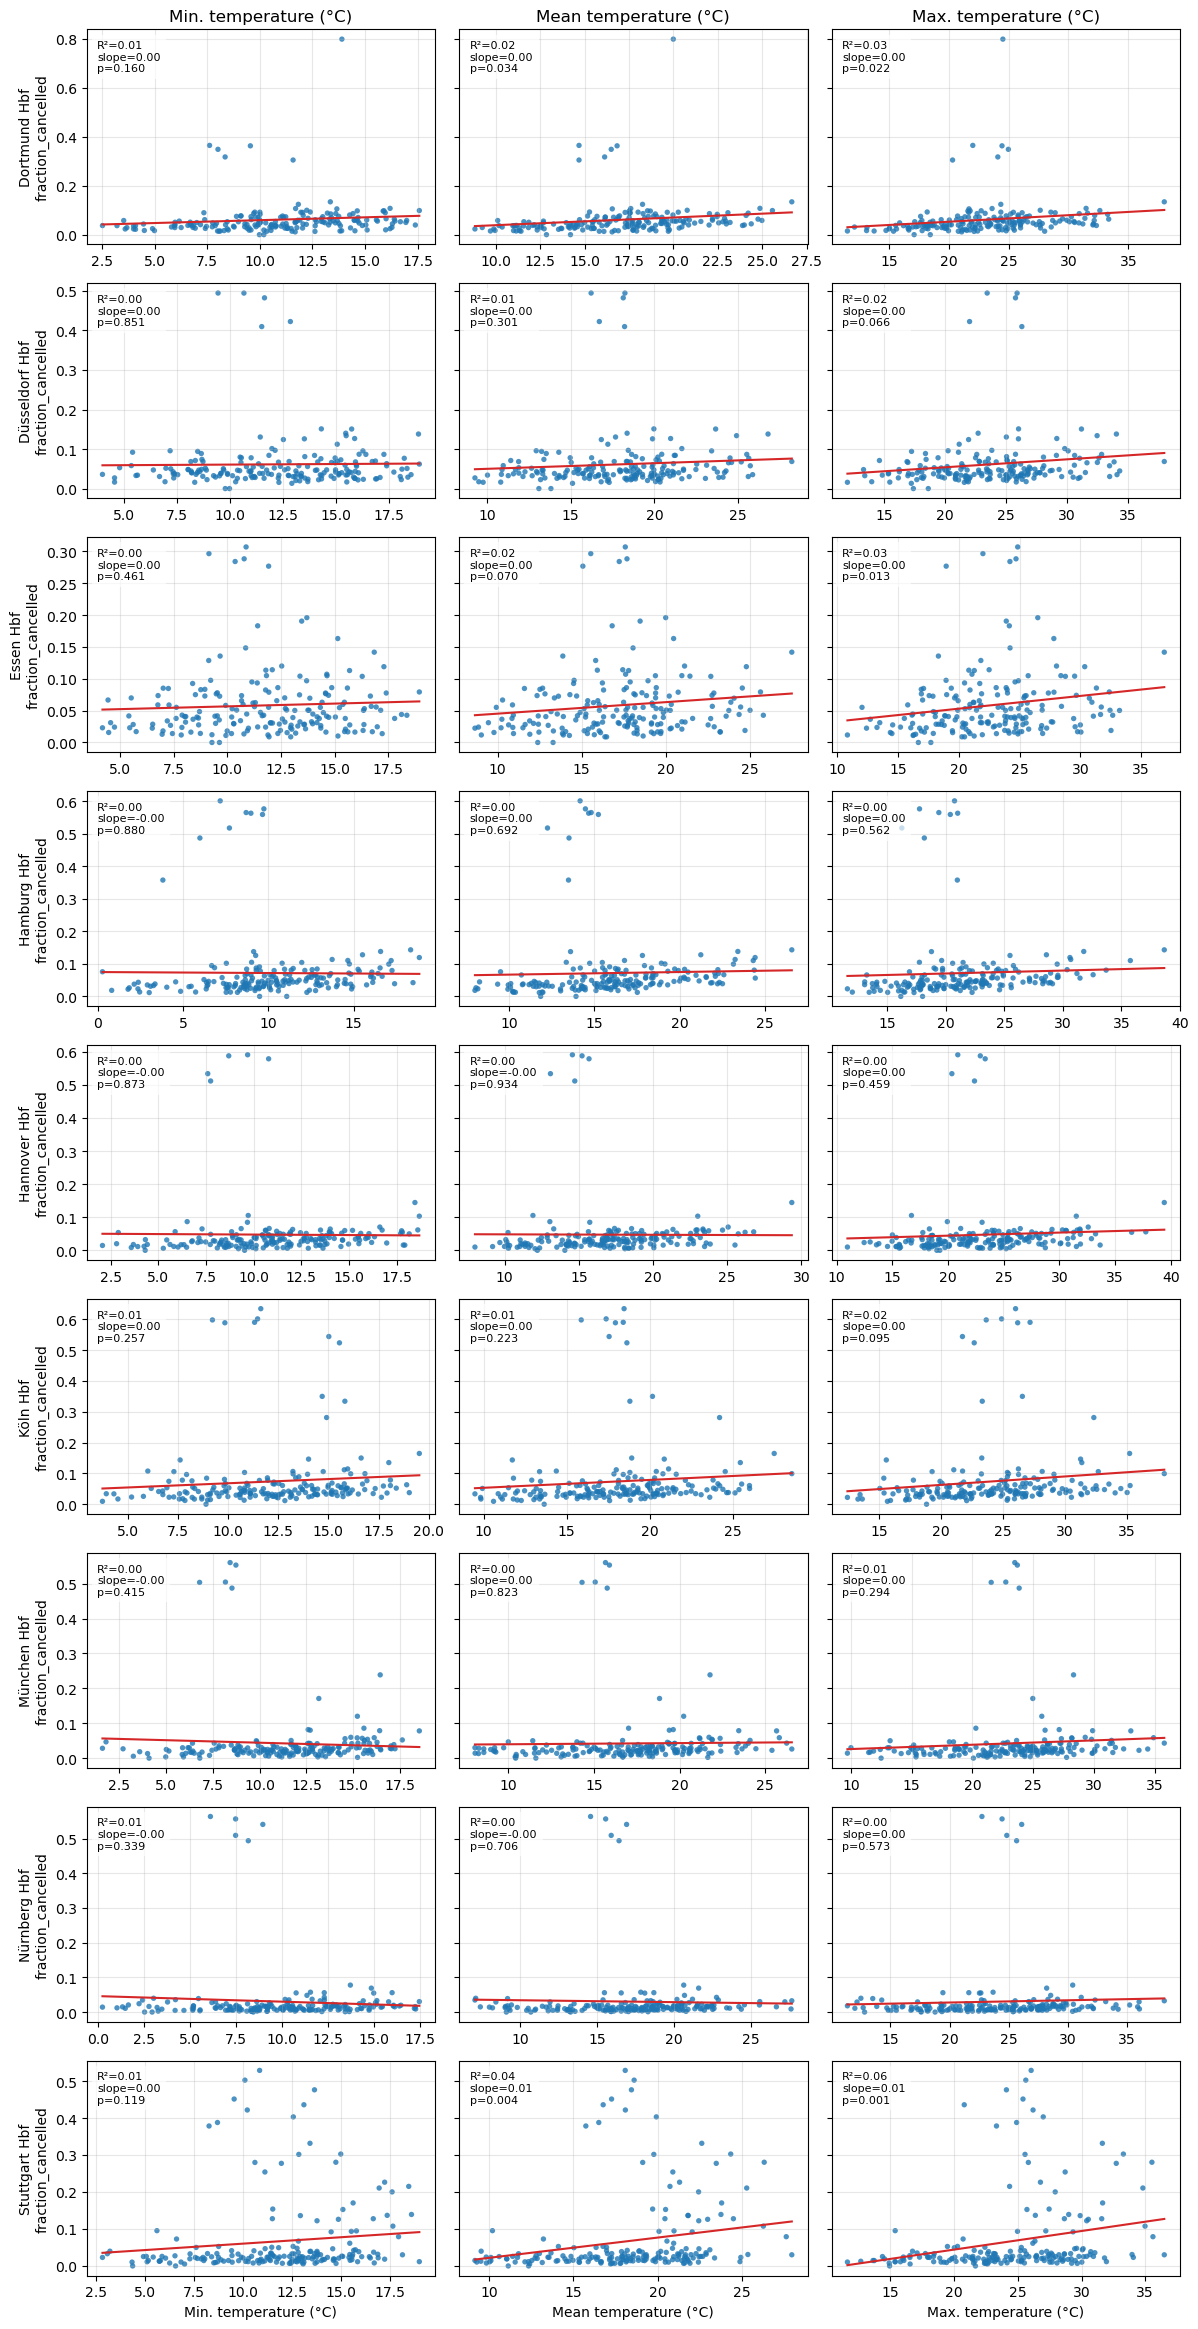

          city variable   n  slope  intercept      r    R2  p_value  stderr_slope
  Dortmund Hbf       tn 185  0.002      0.036  0.104 0.011    0.160         0.002
  Dortmund Hbf       tg 185  0.003      0.007  0.156 0.024    0.034         0.001
  Dortmund Hbf       tx 185  0.003     -0.000  0.168 0.028    0.022         0.001
Düsseldorf Hbf       tn 185  0.000      0.058  0.014 0.000    0.851         0.002
Düsseldorf Hbf       tg 185  0.001      0.036  0.076 0.006    0.301         0.001
Düsseldorf Hbf       tx 185  0.002      0.013  0.136 0.018    0.066         0.001
     Essen Hbf       tn 185  0.001      0.048  0.055 0.003    0.461         0.001
     Essen Hbf       tg 185  0.002      0.027  0.133 0.018    0.070         0.001
     Essen Hbf       tx 185  0.002      0.013  0.182 0.033    0.013         0.001
   Hamburg Hbf       tn 185 -0.000      0.075 -0.011 0.000    0.880         0.002
   Hamburg Hbf       tg 185  0.001      0.059  0.029 0.001    0.692         0.002
   Hamburg Hbf  

In [11]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "fraction_cancelled"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

### Now combine all the data and look only for T > 25 °C

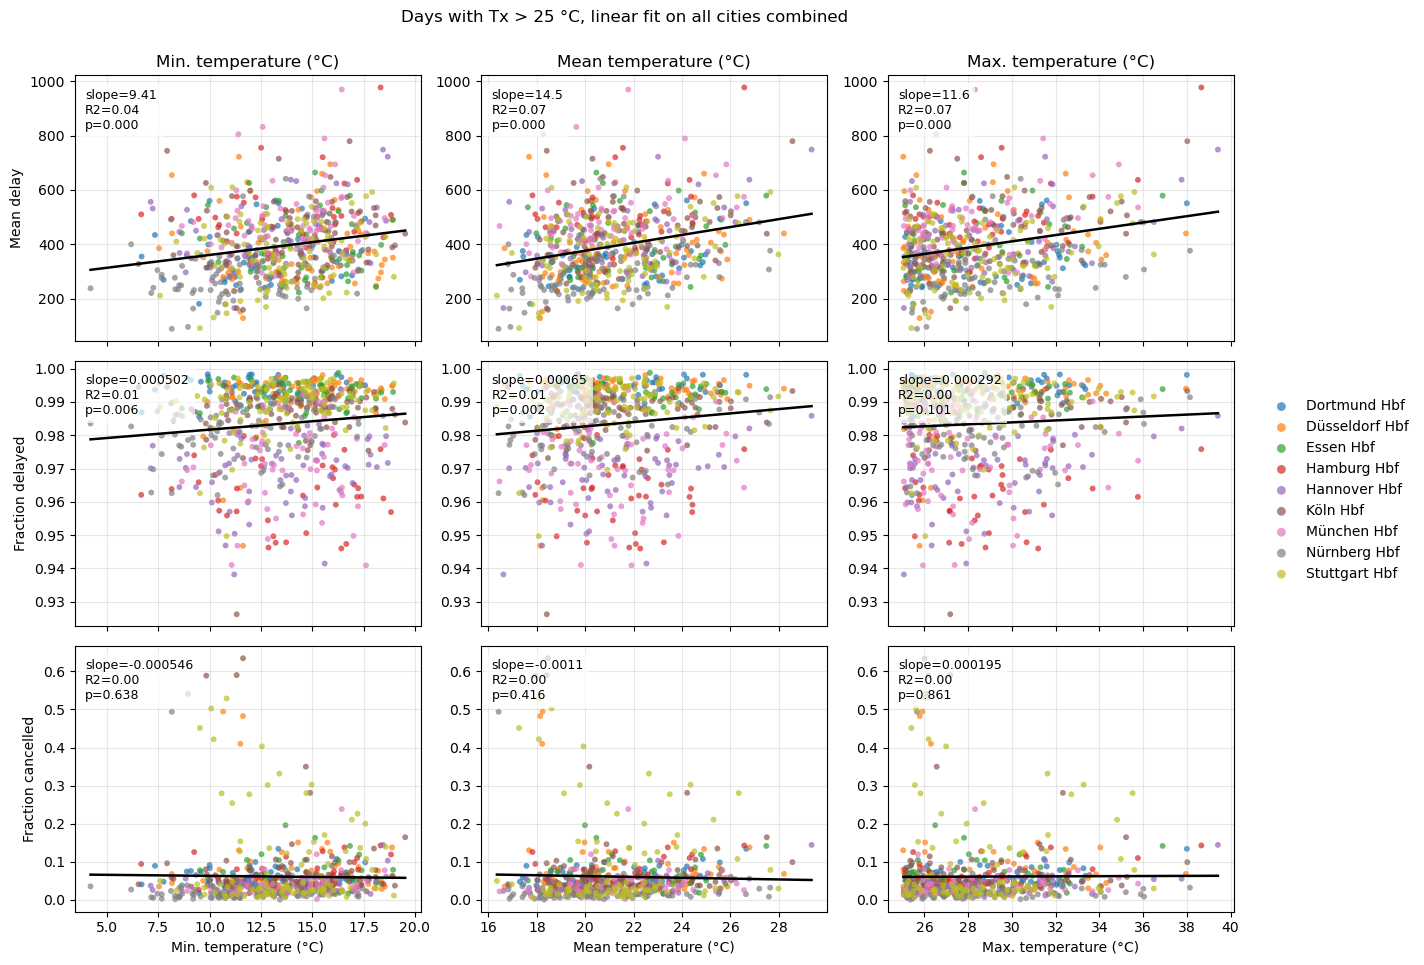

        y_variable x_variable   n   slope  intercept       r     R2  p_value  stderr_slope
        mean_delay         tn 622  9.4099   267.3562  0.2043 0.0417   0.0000        1.8111
        mean_delay         tg 622 14.5045    86.8691  0.2711 0.0735   0.0000        2.0682
        mean_delay         tx 622 11.5611    64.4802  0.2612 0.0682   0.0000        1.7159
  fraction_delayed         tn 622  0.0005     0.9767  0.1091 0.0119   0.0065        0.0002
  fraction_delayed         tg 622  0.0006     0.9697  0.1215 0.0148   0.0024        0.0002
  fraction_delayed         tx 622  0.0003     0.9751  0.0659 0.0043   0.1008        0.0002
fraction_cancelled         tn 622 -0.0005     0.0687 -0.0189 0.0004   0.6380        0.0012
fraction_cancelled         tg 622 -0.0011     0.0846 -0.0327 0.0011   0.4157        0.0013
fraction_cancelled         tx 622  0.0002     0.0558  0.0070 0.0000   0.8611        0.0011


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
TX_MIN = 25
ROWS = ["mean_delay", "fraction_delayed", "fraction_cancelled"]
ROW_LABELS = {"mean_delay": "Mean delay",
              "fraction_delayed": "Fraction delayed",
              "fraction_cancelled": "Fraction cancelled"}
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True)
data = data[data["tx"] > TX_MIN]

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

results = []

fig, axes = plt.subplots(len(ROWS), len(TEMP_COLS),
                         figsize=(4.2 * len(TEMP_COLS), 3.2 * len(ROWS)),
                         sharex="col", squeeze=False)

for i, row in enumerate(ROWS):
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        for city in cities:
            s = data[data["city"] == city]
            ax.scatter(s[var], s[row], s=18, alpha=0.7, edgecolor="none",
                       color=colors[city], label=city)

        # one fit on all cities combined
        sub = data[[var, row]].dropna()
        res = stats.linregress(sub[var], sub[row])
        xs = np.array([sub[var].min(), sub[var].max()])
        ax.plot(xs, res.intercept + res.slope * xs, color="k", lw=1.8)
        ax.text(0.03, 0.95,
                f"slope={res.slope:.3g}\nR2={res.rvalue**2:.2f}\np={res.pvalue:.3f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(fc="white", ec="none", alpha=0.7))

        results.append({"y_variable": row, "x_variable": var, "n": len(sub),
                        "slope": res.slope, "intercept": res.intercept,
                        "r": res.rvalue, "R2": res.rvalue**2,
                        "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(ROW_LABELS[row])
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == len(ROWS) - 1:
            ax.set_xlabel(TEMP_LABELS[var])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           markerscale=1.5, frameon=False)
fig.suptitle(f"Days with Tx > {TX_MIN} °C, linear fit on all cities combined", y=1.0)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(results)
print(summary.round(4).to_string(index=False))

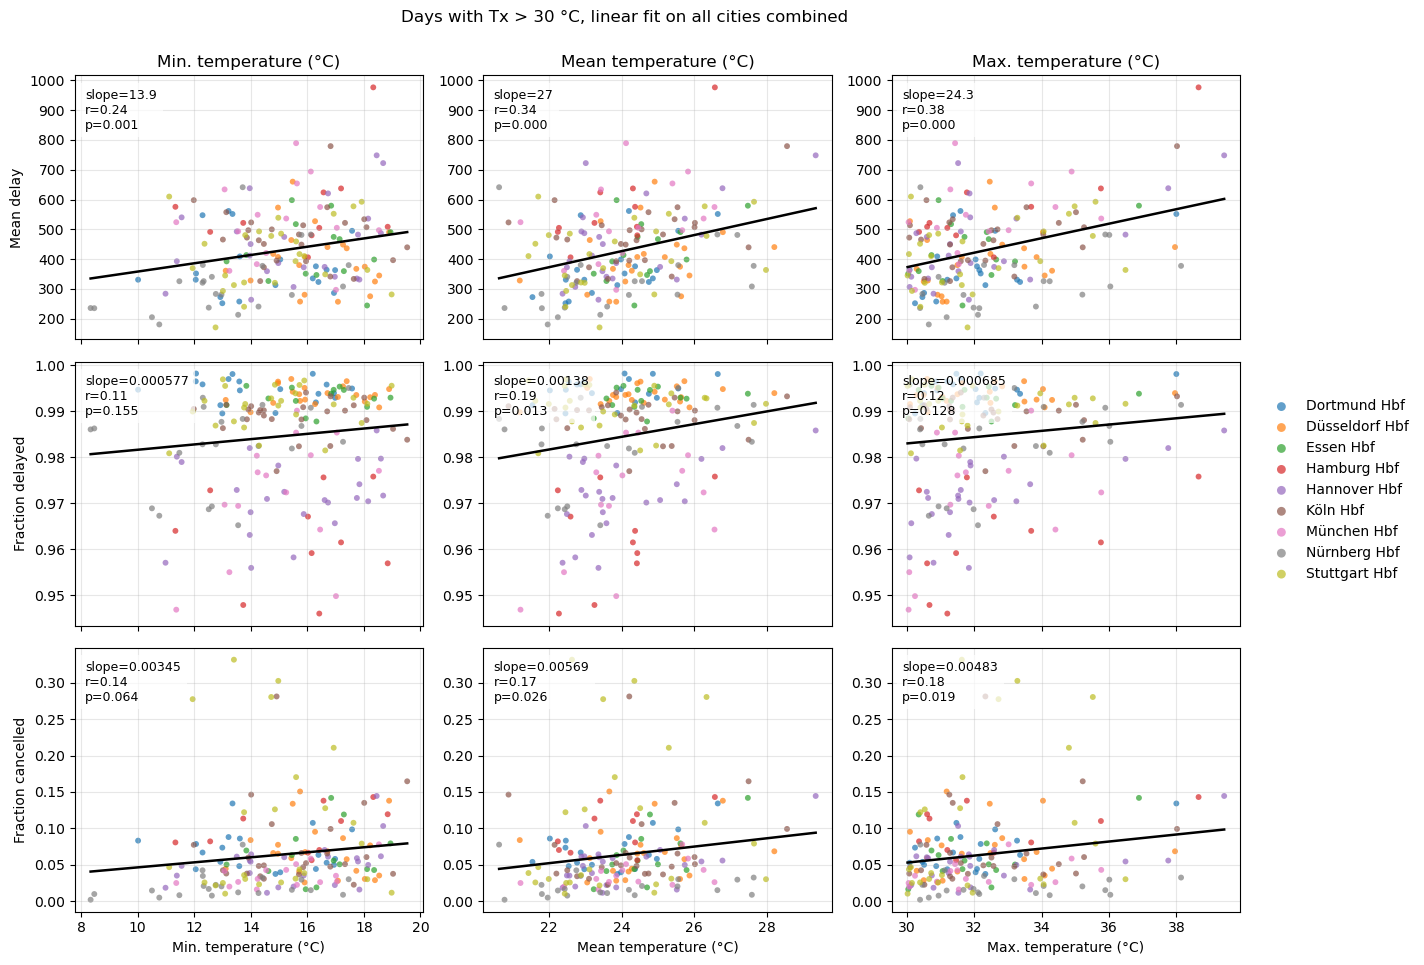

        y_variable x_variable   n   slope  intercept      r     R2  p_value  stderr_slope
        mean_delay         tn 174 13.9074   218.9913 0.2414 0.0583   0.0013        4.2631
        mean_delay         tg 174 26.9502  -220.1268 0.3406 0.1160   0.0000        5.6729
        mean_delay         tx 174 24.3363  -357.3372 0.3810 0.1452   0.0000        4.5029
  fraction_delayed         tn 174  0.0006     0.9759 0.1084 0.0117   0.1546        0.0004
  fraction_delayed         tg 174  0.0014     0.9513 0.1888 0.0356   0.0126        0.0005
  fraction_delayed         tx 174  0.0007     0.9625 0.1160 0.0134   0.1275        0.0004
fraction_cancelled         tn 174  0.0035     0.0119 0.1410 0.0199   0.0635        0.0018
fraction_cancelled         tg 174  0.0057    -0.0730 0.1692 0.0286   0.0257        0.0025
fraction_cancelled         tx 174  0.0048    -0.0920 0.1778 0.0316   0.0189        0.0020


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
TX_MIN = 30
ROWS = ["mean_delay", "fraction_delayed", "fraction_cancelled"]
ROW_LABELS = {"mean_delay": "Mean delay",
              "fraction_delayed": "Fraction delayed",
              "fraction_cancelled": "Fraction cancelled"}
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True)
data = data[data["tx"] > TX_MIN]

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

results = []

fig, axes = plt.subplots(len(ROWS), len(TEMP_COLS),
                         figsize=(4.2 * len(TEMP_COLS), 3.2 * len(ROWS)),
                         sharex="col", squeeze=False)

for i, row in enumerate(ROWS):
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        for city in cities:
            s = data[data["city"] == city]
            ax.scatter(s[var], s[row], s=18, alpha=0.7, edgecolor="none",
                       color=colors[city], label=city)

        # one fit on all cities combined
        sub = data[[var, row]].dropna()
        res = stats.linregress(sub[var], sub[row])
        xs = np.array([sub[var].min(), sub[var].max()])
        ax.plot(xs, res.intercept + res.slope * xs, color="k", lw=1.8)
        ax.text(0.03, 0.95,
                f"slope={res.slope:.3g}\nr={res.rvalue:.2f}\np={res.pvalue:.3f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(fc="white", ec="none", alpha=0.7))

        results.append({"y_variable": row, "x_variable": var, "n": len(sub),
                        "slope": res.slope, "intercept": res.intercept,
                        "r": res.rvalue, "R2": res.rvalue**2,
                        "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(ROW_LABELS[row])
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == len(ROWS) - 1:
            ax.set_xlabel(TEMP_LABELS[var])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           markerscale=1.5, frameon=False)
fig.suptitle(f"Days with Tx > {TX_MIN} °C, linear fit on all cities combined", y=1.0)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(results)
print(summary.round(4).to_string(index=False))